In [1]:
import numpy as np
import matplotlib.pylab as plt
import uproot
import awkward as ak
import seaborn
import RA_funcs as rf
from scipy.signal import find_peaks
from scipy.optimize import curve_fit
from scipy.special import gamma
from scipy.stats import skew
import Scope_funcs as sf


imports work
imports work


In [2]:
# read data for training and filter for chi2
hit_data_scope_1093 = sf.get_ROOT_data_zip_Aligned(1093, return_TLU=False)

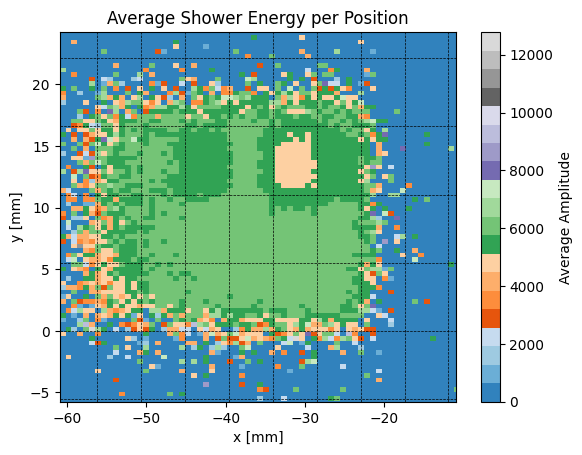

(-35.917829877731826, 9.245747598255482)

In [3]:
sf.avg_energy_scope_colormap(hit_data_scope_1093, y_borders=15)

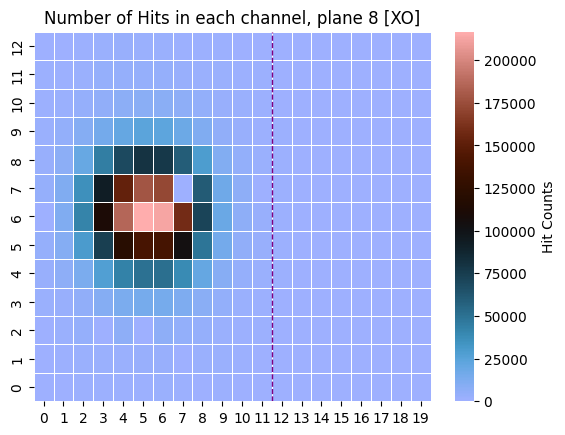

In [4]:
rf.hits_amount_colormap_single_plane(hit_data_scope_1093.hits,8)

<span style="font-family: Comic Sans MS; font-size:25px; color:orange">

PAD RECONSTRUCTION - Neuron Network

Missions:
 - see how the get the inputs faster (maybe get the energies for all pads at one iteration)

In [5]:
import torch
from torch.utils.data import TensorDataset, DataLoader, random_split, Subset, Dataset
import torch.nn as nn
import torch.optim as optim
import glob

<span style="font-family: Comic Sans MS; font-size:25px; color:pink">

Build and Train NN Model

In [6]:
# get array with the energies per event for a specified pad
def get_energies_of_pad(data_scope, plane, pad):
    """returns a list of the energies in the pad in each event"""

    # energies of the plane and pad
    hit_ch = data_scope.hits[data_scope.hits.ch == pad]
    ch_pl_amp = hit_ch[hit_ch.plane == plane].amp

    # energies in the pad (including zeros)
    ch_pl_amp_zeros = ak.fill_none(ak.pad_none(ch_pl_amp, 1, axis=-1), 0)
    
    # take only events with 1 energy value
    pad_energies = ch_pl_amp_zeros[ak.num(ch_pl_amp_zeros) == 1]

    return pad_energies

In [7]:
pad_energies = get_energies_of_pad(hit_data_scope_1093, 4, 125)
len(pad_energies)

440918

In [114]:
# return a list of 11 inputs per pad, each term is the data for the neighboring pads and plane number of 1 event
def get_inputs_for_NN1(data_scope, plane, pad):
    """returns the input torch tensor for specific plane and pad (plane from 0 to 7)
        Inputs:
            8 neighbor energies
            previous plane energy
            next plane energy
            normalized plane index"""

    N = len(data_scope)

    inputs = []
    
    # 1. get the neighbors pads' energies
    
    # energies of the neighboring pads in the same plane
    for neighbor_pad in [pad-21,pad-20,pad-19, pad-1,pad+1, pad+19,pad+20,pad+21]:
        
        E_neighbor = get_energies_of_pad(data_scope, plane, neighbor_pad)
        inputs.append(E_neighbor)

    # energies in previous plane
    E_prev = get_energies_of_pad(data_scope, plane-1, pad)
    inputs.append(E_prev)

    # energies in next plane
    E_next = get_energies_of_pad(data_scope, plane+1, pad)
    inputs.append(E_next)

    # 2. normalized plane array
    plane_norm = ak.singletons(np.full(N,plane/7))
    inputs.append(plane_norm)
    
    # 3. combine all arrays in inputs to 1 [N,11] array
    combined_inputs = ak.concatenate(inputs, axis=1)
    
    return combined_inputs


# inputs in awkward
total_inputs = get_inputs_for_NN1(hit_data_scope_1093, 3, 125)



In [105]:
total_inputs

<Array [[16, 0, 0, 0, ..., 0, 0, 0, 0.429], ...] type='440918 * var * float64'>

In [117]:
# convert ak data to torch tensor
X = ak.to_torch(total_inputs[:,0:8]).float()

# get the pad outputs
y = ak.to_torch(get_energies_of_pad(hit_data_scope_1093, 3, 125)).float()

print(X.shape, y.shape)

torch.Size([440918, 8]) torch.Size([440918, 1])


In [141]:
# Baseline MSE (loss between the y values and the average y)
y_mean = y.mean()

baseline_predictions = torch.full_like(y, y_mean)

baseline_mse = torch.mean((y - baseline_predictions)**2)
baseline_mae = torch.mean(-(y - baseline_predictions))

print(baseline_mse, baseline_mae)

tensor(32837.5117) tensor(1.0206e-05)


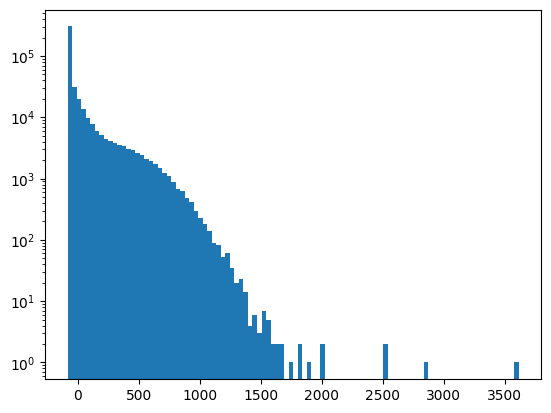

In [139]:

# Your calculation
a = (y - baseline_predictions)

# Correct conversion: detach, move to cpu, then call .numpy()
b = a.detach().cpu().numpy()

# Plot the histogram
plt.hist(b, bins=100)
plt.yscale("log")
plt.show()


TypeError: object of type 'builtin_function_or_method' has no len()

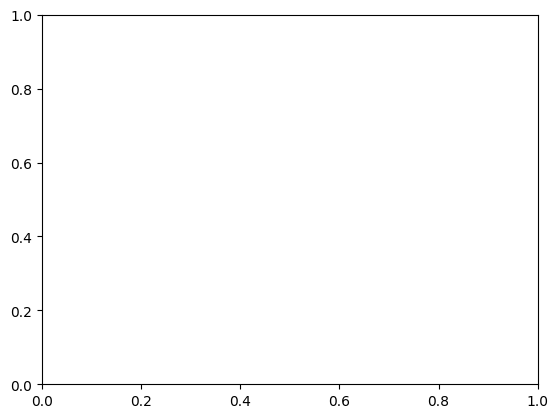

In [134]:
a = (y - baseline_predictions)**2
b = a.numpy
plt.hist(b)


In [130]:
max(y) - y_mean

tensor([3612.3604])

In [126]:
y_mean

tensor(83.6396)

In [ ]:
# create class to define objects of the datasets
class CaloDataset(Dataset):

    def __init__(self, X, y):
        self.X = X.float()
        self.y = y.float()

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]
    


# divide data to train and evaluation datasets for training (ver1)
dataset = CaloDataset(X, y)

train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size

train_dataset, val_dataset = random_split(dataset, [train_size, val_size])


# divide the data into batches for the training
train_loader = DataLoader(train_dataset, batch_size=2048, shuffle=True)

val_loader = DataLoader(val_dataset, batch_size=2048)


# get the mean and std of each input to later normalize
train_indices = train_dataset.indices
X_train = X[train_indices] # get the input data for trainig
mean = X_train.mean(dim=0)
std = X_train.std(dim=0) + 1e-8




# add a constant layer for normalization before the first layer
class Normalize(nn.Module):
    def __init__(self, mean, std):
        super().__init__()
        self.register_buffer("mean", mean)
        self.register_buffer("std", std)

    def forward(self, x):
        return (x - self.mean) / self.std
    
    

# define the NN model
class PixelPredictor(nn.Module):

    def __init__(self, mean, std):
        super().__init__()

        self.model = nn.Sequential(
            Normalize(mean, std),

            nn.Linear(len(X[1]), 64),
            nn.ReLU(),

            nn.Linear(64, 64),
            nn.ReLU(),

            nn.Linear(64, 64),
            nn.ReLU(),

            nn.Linear(64, 1)
        )

    def forward(self, x):
        return self.model(x).squeeze(-1)
    

# define loss function
criterion = nn.MSELoss()

# define the optimizer (What is this exactly?)
model = PixelPredictor(mean, std)

optimizer = optim.Adam(model.parameters(), lr=0.001)

In [123]:
# run the training loop
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
num_epochs = 10

for epoch in range(num_epochs):

    model.train()
    model = model.to(device)
    total_loss = 0
    total_samples = 0

    for inputs, targets in train_loader:

        inputs = inputs.to(device) # what is to.device?
        targets = targets.to(device)

        predictions = model(inputs)

        loss = criterion(predictions, targets)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * inputs.size(0)
        total_samples += inputs.size(0)


    train_loss = total_loss / total_samples
    print(train_loss)

/Users/bentalmor/Desktop/LUXE/F-Cal-TB-Project/venv_312/lib/python3.12/site-packages/torch/nn/modules/loss.py:535: UserWarning: Using a target size (torch.Size([2048, 1])) that is different to the input size (torch.Size([2048])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)
/Users/bentalmor/Desktop/LUXE/F-Cal-TB-Project/venv_312/lib/python3.12/site-packages/torch/nn/modules/loss.py:535: UserWarning: Using a target size (torch.Size([478, 1])) that is different to the input size (torch.Size([478])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


35508.07481640291
33153.06448863999
33071.662201534564
33030.0630900117
33018.290728847285
33014.700030976775
33012.57838388178
33014.387566857215
33015.89978716921
33013.325415163235


In [ ]:
# run the evaluation loader on the model to test the model
model.eval()
val_loss = 0
total_samples = 0

with torch.no_grad():
    for inputs, targets in val_loader:

        inputs = inputs.to(device)
        targets = targets.to(device)

        predictions = model(inputs)

        loss = criterion(predictions, targets)

        val_loss += loss.item() * inputs.size(0)
        total_samples += inputs.size(0)


val_total_loss = val_loss / total_samples

print(f"Epoch {epoch+1}: train={train_loss:.4f}  val={val_loss:.4f}")

<span style="font-family: Comic Sans MS; font-size:25px; color:pink">

Apply the Model to Predict Pad Energies

<span style="font-family: Comic Sans MS; font-size:15px; color:pink">

# Compare the NN. results with Actual Data

In [24]:

def compare_NN_with_og_data(data_scope, plane, pad, NN_model=False):

    # get the data for the pad
    pad_energies = get_energies_of_pad(data_scope, plane, pad)

    # get the input data for the NN model
    inputs = get_inputs_for_NN1(data_scope, plane, pad).numpy()
    inputs_for_NN = ak.Array(inputs[:,0:10])

    # compensation by average of the inputs
    compensated = ak.mean(inputs_for_NN, axis=1)

    return pad_energies, compensated

In [25]:
pad_energies,compensated = compare_NN_with_og_data(hit_data_scope_1093,3,125)

In [26]:
# len(pad_energies)
compensated

<Array [3, 6.9, 0, 4.3, 11.4, ..., 42.6, 0, 0, 0, 0] type='440918 * float64'>

In [27]:
def hist_of_the_loss(pad_energies, compensated):

    residuals = pad_energies - compensated

    mean = ak.mean(residuals)
    std = ak.std(residuals)

    fig, ax = plt.subplots(2, 1, figsize=(8,8), sharex=False)

    # Top: energy distributions
    ax[0].hist(pad_energies, bins=200, alpha=0.6, label="True energy")
    ax[0].hist(compensated, bins=200, alpha=0.6, label="NN prediction")
    ax[0].set_ylabel("Counts")
    ax[0].legend()
    ax[0].set_title("Energy distributions")

    # Bottom: residuals
    ax[1].hist(residuals, bins=200, alpha=0.7)
    ax[1].axvline(mean, color='r', linestyle='--', label=f"Mean = {mean:.3f}")
    ax[1].axvline(mean + std, color='g', linestyle=':', label=f"σ = {std:.3f}")
    ax[1].axvline(mean - std, color='g', linestyle=':')
    
    ax[1].set_xlabel("Residual |True - Predicted|")
    ax[1].set_ylabel("Counts")
    ax[1].legend()
    ax[1].set_title("Residual distribution")

    plt.tight_layout()
    plt.show()

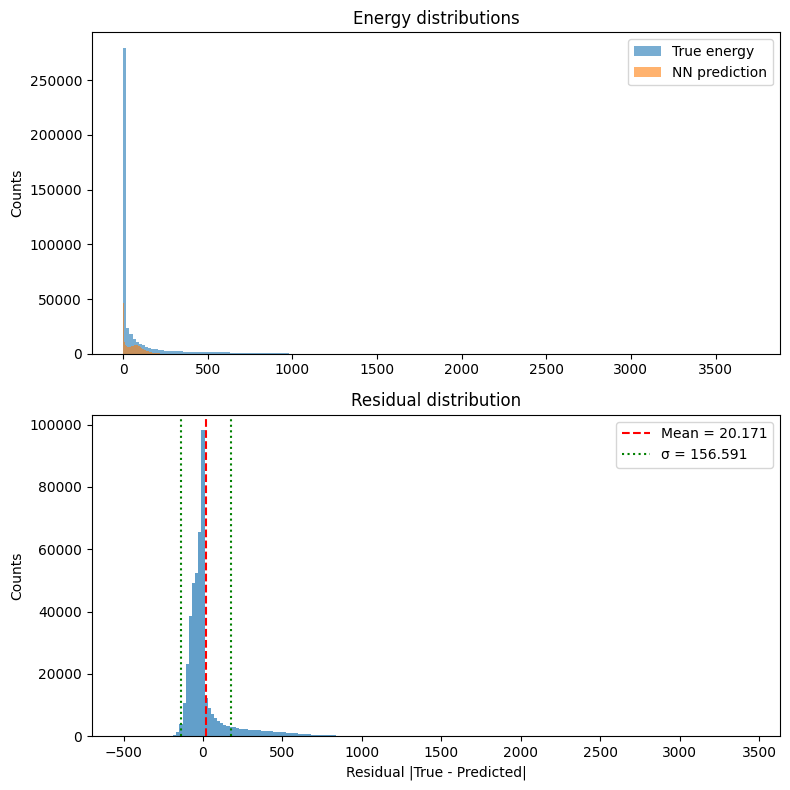

In [28]:
hist_of_the_loss(pad_energies,compensated)

In [47]:
# take all the data where the target outputs are not zero
b = ak.Array(y.numpy())
mask = b == 0
mask = ak.flatten(mask)

# take all the inputs corresponding to the non 0 targets
a = ak.Array(X.numpy())


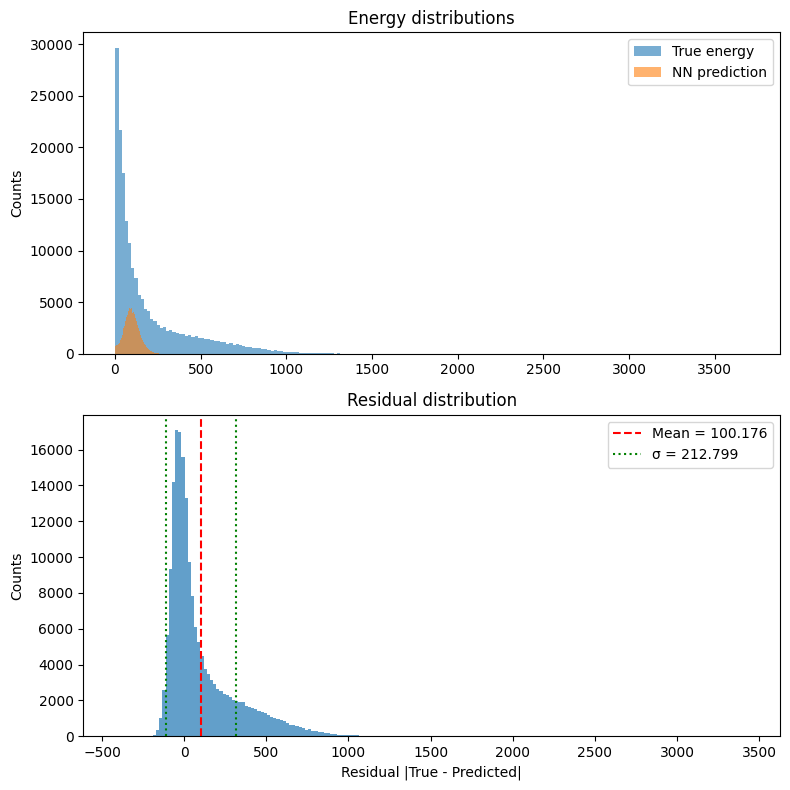

In [50]:
hist_of_the_loss(ak.flatten(b[~mask]), ak.mean(a[~mask][:,0:10], axis=1))